# D2C Customer Churn Intelligence
## Part 1 – Data Audit, EDA & Business Understanding

Name: YOUR NAME
Student ID: YOUR ID

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

zip_path = "d2c churn data package-20260615T085556Z-3-001.zip"

z = zipfile.ZipFile(zip_path)

print(z.namelist())

['d2c churn data package/intervention_history.csv', 'd2c churn data package/churn_labels.csv', 'd2c churn data package/web_events_snapshot.csv', 'd2c churn data package/customers.csv', 'd2c churn data package/orders.csv', 'd2c churn data package/rfm_modeling_snapshot.csv', 'd2c churn data package/DATA_DICTIONARY.md', 'd2c churn data package/STUDENT_FACING_PROBLEM_STATEMENT.md', 'd2c churn data package/support_tickets.csv']


In [ ]:
customers = pd.read_csv(
    z.open('d2c churn data package/customers.csv')
)

orders = pd.read_csv(
    z.open('d2c churn data package/orders.csv')
)

tickets = pd.read_csv(
    z.open('d2c churn data package/support_tickets.csv')
)

web = pd.read_csv(
    z.open('d2c churn data package/web_events_snapshot.csv')
)

campaigns = pd.read_csv(
    z.open('d2c churn data package/intervention_history.csv')
)

churn = pd.read_csv(
    z.open('d2c churn data package/churn_labels.csv')
)

snapshot = pd.read_csv(
    z.open('d2c churn data package/rfm_modeling_snapshot.csv')
)

In [ ]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web": web,
    "campaigns": campaigns,
    "churn": churn,
    "snapshot": snapshot
}

for name, df in datasets.items():
    print(name)
    print(df.shape)
    print("-"*40)

customers
(2400, 9)
----------------------------------------
orders
(10009, 10)
----------------------------------------
tickets
(1921, 8)
----------------------------------------
web
(2400, 10)
----------------------------------------
campaigns
(2400, 5)
----------------------------------------
churn
(2400, 4)
----------------------------------------
snapshot
(2400, 29)
----------------------------------------


In [ ]:
for name, df in datasets.items():

    print(f"\n{name}")

    print("Missing Values")
    print(df.isna().sum())

    print("\nDuplicates")
    print(df.duplicated().sum())

    print("="*60)


customers
Missing Values
customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

Duplicates
0

orders
Missing Values
order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

Duplicates
0

tickets
Missing Values
ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64

Duplicates
0

web
Missing Values
customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        

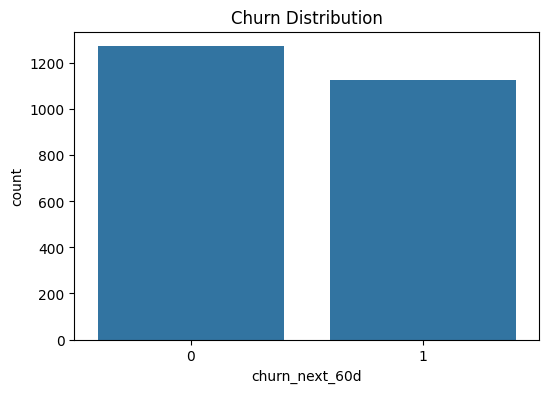

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=churn,
    x='churn_next_60d'
)

plt.title("Churn Distribution")
plt.show()

In [ ]:
churn_rate = churn["churn_next_60d"].mean()

print(
    f"Overall churn rate = {churn_rate:.2%}"
)

Overall churn rate = 46.96%


In [ ]:
for name, df in datasets.items():
    print(name)
    print(df.shape)

customers
(2400, 9)
orders
(10009, 10)
tickets
(1921, 8)
web
(2400, 10)
campaigns
(2400, 5)
churn
(2400, 4)
snapshot
(2400, 30)


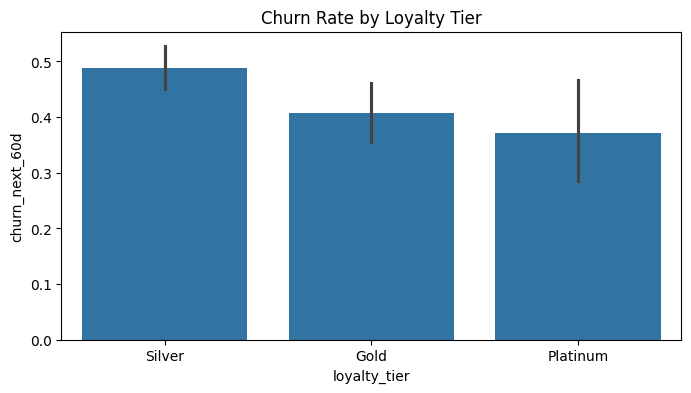

In [ ]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=snapshot,
    x='loyalty_tier',
    y='churn_next_60d'
)

plt.title("Churn Rate by Loyalty Tier")
plt.show()

In [ ]:
snapshot['recency_bucket'] = pd.qcut(
    snapshot['recency_days'],
    q=4
)

snapshot.groupby(
    'recency_bucket'
)['churn_next_60d'].mean()

/tmp/ipykernel_4977/1034649414.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snapshot.groupby(


,churn_next_60d
recency_bucket,
"(-0.001, 25.0]",0.097521
"(25.0, 66.0]",0.308581
"(66.0, 129.0]",0.587140
"(129.0, 562.0]",0.892977


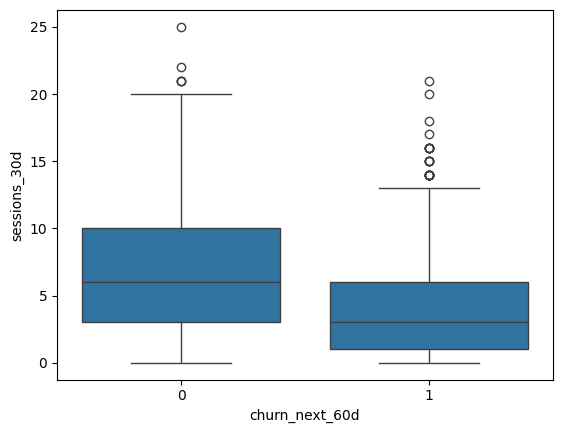

In [ ]:
sns.boxplot(
    data=snapshot,
    x='churn_next_60d',
    y='sessions_30d'
)

plt.show()

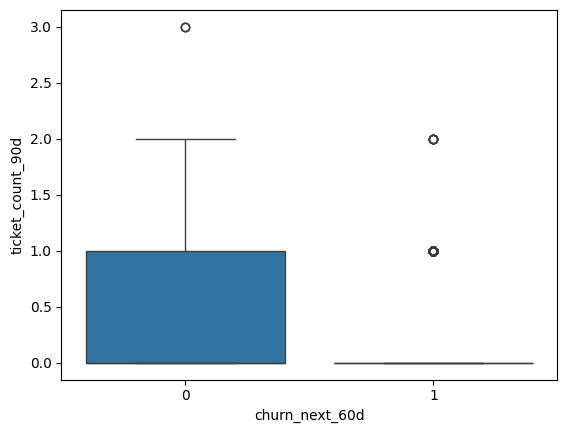

In [ ]:
sns.boxplot(
    data=snapshot,
    x='churn_next_60d',
    y='ticket_count_90d'
)

plt.show()

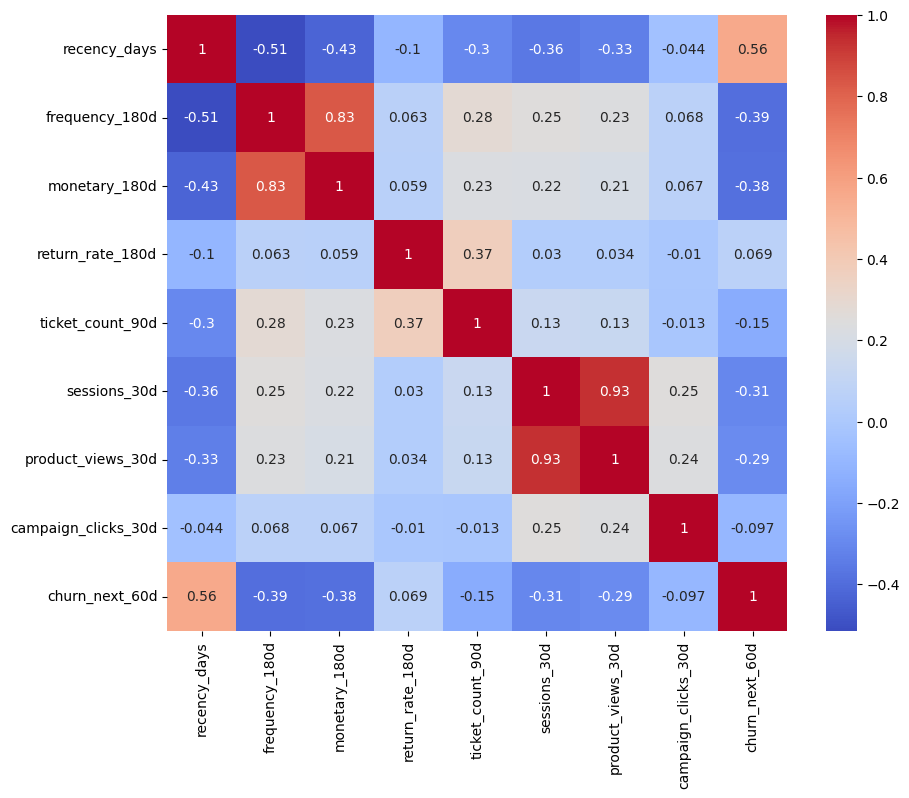

In [ ]:
numeric_cols = [
    'recency_days',
    'frequency_180d',
    'monetary_180d',
    'return_rate_180d',
    'ticket_count_90d',
    'sessions_30d',
    'product_views_30d',
    'campaign_clicks_30d',
    'churn_next_60d'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    snapshot[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

## Churn Risk Hypotheses

## Churn Risk Hypotheses

### Hypothesis 1

Customers with longer periods of inactivity (high recency) have significantly higher churn rates.

### Evidence

Churn increases from 9.75% among the most recent purchasers to 89.30% among the least recent purchasers.

### Hypothesis 2

Silver-tier customers are more likely to churn than Gold and Platinum customers.

### Evidence

Silver customers show a churn rate of 48.81%, compared with 40.75% for Gold and 37.14% for Platinum.

### Hypothesis 3

Customers with lower purchase frequency are more likely to churn.

### Hypothesis 4

Customers with lower web engagement are more likely to churn.

### Hypothesis 5

Customers with higher support-ticket activity are more likely to churn.


In [ ]:
print(z.namelist())

['d2c churn data package/intervention_history.csv', 'd2c churn data package/churn_labels.csv', 'd2c churn data package/web_events_snapshot.csv', 'd2c churn data package/customers.csv', 'd2c churn data package/orders.csv', 'd2c churn data package/rfm_modeling_snapshot.csv', 'd2c churn data package/DATA_DICTIONARY.md', 'd2c churn data package/STUDENT_FACING_PROBLEM_STATEMENT.md', 'd2c churn data package/support_tickets.csv']


In [16]:
import pandas as pd
import zipfile

zip_path = "d2c churn data package-20260615T085556Z-3-001.zip"

z = zipfile.ZipFile(zip_path)

snapshot = pd.read_csv(
    z.open('d2c churn data package/rfm_modeling_snapshot.csv')
)

print(snapshot.shape)

(2400, 29)


In [17]:
snapshot.groupby(
    'loyalty_tier'
)['churn_next_60d'].mean().sort_values(ascending=False)

,churn_next_60d
loyalty_tier,
Silver,0.488136
Gold,0.407524
Platinum,0.371429


In [18]:
snapshot.groupby(
    pd.qcut(snapshot['recency_days'], 4)
)['churn_next_60d'].mean()

/tmp/ipykernel_4977/2679599942.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snapshot.groupby(


,churn_next_60d
recency_days,
"(-0.001, 25.0]",0.097521
"(25.0, 66.0]",0.308581
"(66.0, 129.0]",0.587140
"(129.0, 562.0]",0.892977


In [19]:
snapshot.columns.tolist()

['customer_id',
 'snapshot_date',
 'city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'marketing_consent',
 'recency_days',
 'frequency_180d',
 'monetary_180d',
 'return_rate_180d',
 'avg_discount_pct_180d',
 'avg_rating_180d',
 'category_diversity_180d',
 'ticket_count_90d',
 'negative_ticket_rate_90d',
 'avg_resolution_hours_90d',
 'days_since_signup',
 'sessions_30d',
 'product_views_30d',
 'cart_adds_30d',
 'wishlist_adds_30d',
 'abandoned_carts_30d',
 'email_opens_30d',
 'campaign_clicks_30d',
 'last_visit_days_ago',
 'churn_next_60d',
 'split']